In [ ]:
import torch
import torch.nn as nn
from torchvision import models
from collections import defaultdict
from torch.utils.data import Subset
from torch.utils.data import DataLoader
import torch.nn.functional as F

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

backbone = models.resnet50(pretrained=True)

# keep all layers except the final fully connected
modules = list(backbone.children())[:-1]
feature_extractor = nn.Sequential(*modules).to(device)

# unfreeze only the last block
for name, param in feature_extractor.named_parameters():
    param.requires_grad = name.startswith("7") or "layer4" in name

Using device: cuda


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
from torchvision import datasets, transforms, models

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_dataset = datasets.Flowers102('data', split = 'train', download=True, transform = transform)
validation_dataset = datasets.Flowers102('data', split = 'val', download=True, transform = transform)
test_dataset = datasets.Flowers102('data', split = 'test', download=True, transform = transform)

val_loader  = DataLoader(validation_dataset, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset,        batch_size=128, shuffle=False)

In [ ]:
def make_k_shot_subset(dataset, k):
    class_to_indices = defaultdict(list)

    for idx in range(len(dataset)):
        _, label = dataset[idx]
        if len(class_to_indices[label]) < k:
            class_to_indices[label].append(idx)

    selected_indices = []
    for label, indices in class_to_indices.items():
        selected_indices.extend(indices)

    return Subset(dataset, selected_indices)

k_3_shot_dataset = make_k_shot_subset(train_dataset, k=3)
k_5_shot_dataset = make_k_shot_subset(train_dataset, k=5)

In [ ]:
def compute_prototypes(feature_extractor, support_dataset, batch_size=64):
    loader = DataLoader(support_dataset, batch_size=batch_size, shuffle=False)
    feature_extractor.eval()

    class_to_feats = defaultdict(list)

    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            y = y.to(device)

            feats = feature_extractor(X)
            feats = feats.squeeze(-1).squeeze(-1)

            for f, label in zip(feats, y):
                class_to_feats[int(label.item())].append(f.cpu())

    # compute the mean per class
    classes = sorted(class_to_feats.keys())
    prototypes = []

    for c in classes:
        stack = torch.stack(class_to_feats[c], dim=0)
        proto = stack.mean(dim=0)
        #mean = stack.mean(dim=0)
        #dists = torch.norm(stack - mean, dim=1)
        #weights = torch.softmax(-dists, dim=0)
        #proto = torch.sum(stack * weights.unsqueeze(1), dim=0)
        prototypes.append(proto)

    prototypes = torch.stack(prototypes, dim=0)
    return prototypes.to(device), classes

In [ ]:
# using euclidean distance
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np
import torch.nn.functional as F

def evaluate_euclidean_with_cm(feature_extractor, prototypes, classes, dataloader):
    feature_extractor.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            feats = feature_extractor(X)
            feats = feats.squeeze(-1).squeeze(-1)

            dists = torch.cdist(feats, prototypes)
            nearest_idx = torch.argmin(dists, dim=1)
            pred_labels = torch.tensor(
                [classes[i] for i in nearest_idx.cpu()],
                device=device
            )

            all_preds.extend(pred_labels.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    return np.array(all_preds), np.array(all_labels)

In [ ]:
def fine_tune_resnet(model, support_loader, val_loader=None, lr=1e-4, max_epochs=50, patience=3, min_delta=1e-4):
    model.train()
    linear_head = nn.Linear(2048, 102).to(device)

    params = list(filter(lambda p: p.requires_grad, model.parameters())) + list(linear_head.parameters())
    optimizer = torch.optim.Adam(params, lr=lr)
    criterion = nn.CrossEntropyLoss()

    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []

    best_val_acc = 0.0
    patience_counter = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        linear_head.train()
        epoch_train_loss = 0.0
        train_correct = 0
        train_total = 0

        for X, y in support_loader:
            X, y = X.to(device), y.to(device)

            feats = model(X)
            feats = feats.view(feats.size(0), -1)
            logits = linear_head(feats)
            loss = criterion(logits, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_train_loss += loss.item()

            preds = torch.argmax(logits, dim=1)
            train_correct += (preds == y).sum().item()
            train_total += y.size(0)

        avg_train_loss = epoch_train_loss / len(support_loader)
        train_accuracy = train_correct / train_total

        train_losses.append(avg_train_loss)
        train_accuracies.append(train_accuracy)

        print(f"Epoch {epoch} - Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.4f}")

        if val_loader is not None:
            val_loss, val_acc = evaluate_val_metrics(model, linear_head, val_loader, criterion)
            val_losses.append(val_loss)
            val_accuracies.append(val_acc)

            print(f"           Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

            if val_acc - best_val_acc > min_delta:
                best_val_acc = val_acc
                patience_counter = 0
                best_model_state = {
                    'model': model.state_dict(),
                    'linear_head': linear_head.state_dict()
                }
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping at epoch {epoch} (best val acc: {best_val_acc:.4f})")
                    break
        else:
            val_losses.append(None)
            val_accuracies.append(None)

    # load best model
    if val_loader is not None and 'best_model_state' in locals():
        model.load_state_dict(best_model_state['model'])
        linear_head.load_state_dict(best_model_state['linear_head'])

    model.eval()
    linear_head.eval()

    return model, linear_head, {
        'train_losses': train_losses,
        'train_accuracies': train_accuracies,
        'val_losses': val_losses,
        'val_accuracies': val_accuracies
    }

In [ ]:
def evaluate_val_metrics(model, linear_head, dataloader, criterion):
    model.eval()
    linear_head.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            feats = model(X)
            feats = feats.view(feats.size(0), -1)
            logits = linear_head(feats)

            loss = criterion(logits, y)
            val_loss += loss.item()

            preds = torch.argmax(logits, dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    avg_val_loss = val_loss / len(dataloader)
    val_accuracy = correct / total

    return avg_val_loss, val_accuracy

In [ ]:
import matplotlib.pyplot as plt

def plot_training_curves(history, title="Training Curves"):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # losses curve
    ax1.plot(history['train_losses'], label='Training Loss', color='blue', linewidth=2)
    if any(loss is not None for loss in history['val_losses']):
        ax1.plot(history['val_losses'], label='Validation Loss', color='red', linewidth=2)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title(f'{title} - Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # accuracy curves
    ax2.plot(history['train_accuracies'], label='Training Accuracy', color='blue', linewidth=2)
    if any(acc is not None for acc in history['val_accuracies']):
        ax2.plot(history['val_accuracies'], label='Validation Accuracy', color='red', linewidth=2)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title(f'{title} - Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

##5-shot


In [ ]:
k = 5
support_5 = make_k_shot_subset(train_dataset, k=k)
support_loader = DataLoader(support_5, batch_size=32, shuffle=True)

print("\nFine-tuning with Early Stopping...")
feature_extractor, linear_head, history = fine_tune_resnet(
    feature_extractor,
    support_loader,
    val_loader=val_loader,
    lr=5e-4,
    max_epochs=20,
    patience=3,
    min_delta=1e-3
)

print("\nEvaluating with Euclidean method...")
prototypes_5, classes_5 = compute_prototypes(feature_extractor, support_5)
preds_euc, labels_euc = evaluate_euclidean_with_cm(feature_extractor, prototypes_5, classes_5, test_loader)


Fine-tuning with Early Stopping...
Epoch 1 - Train Loss: 4.3638, Train Acc: 0.1294
           Val Loss: 2.4673, Val Acc: 0.4510
Epoch 2 - Train Loss: 1.6223, Train Acc: 0.8216
           Val Loss: 1.7925, Val Acc: 0.7402
Epoch 3 - Train Loss: 0.3933, Train Acc: 0.9804
           Val Loss: 1.2453, Val Acc: 0.7931
Epoch 4 - Train Loss: 0.1050, Train Acc: 0.9941
           Val Loss: 0.9200, Val Acc: 0.8176
Epoch 5 - Train Loss: 0.0482, Train Acc: 0.9941
           Val Loss: 0.8480, Val Acc: 0.8225
Epoch 6 - Train Loss: 0.0254, Train Acc: 0.9980
           Val Loss: 0.7960, Val Acc: 0.8284
Epoch 7 - Train Loss: 0.0120, Train Acc: 1.0000
           Val Loss: 0.7447, Val Acc: 0.8363
Epoch 8 - Train Loss: 0.0076, Train Acc: 1.0000
           Val Loss: 0.7174, Val Acc: 0.8461
Epoch 9 - Train Loss: 0.0054, Train Acc: 1.0000
           Val Loss: 0.6970, Val Acc: 0.8490
Epoch 10 - Train Loss: 0.0045, Train Acc: 1.0000
           Val Loss: 0.6831, Val Acc: 0.8549
Epoch 11 - Train Loss: 0.0044, Tr

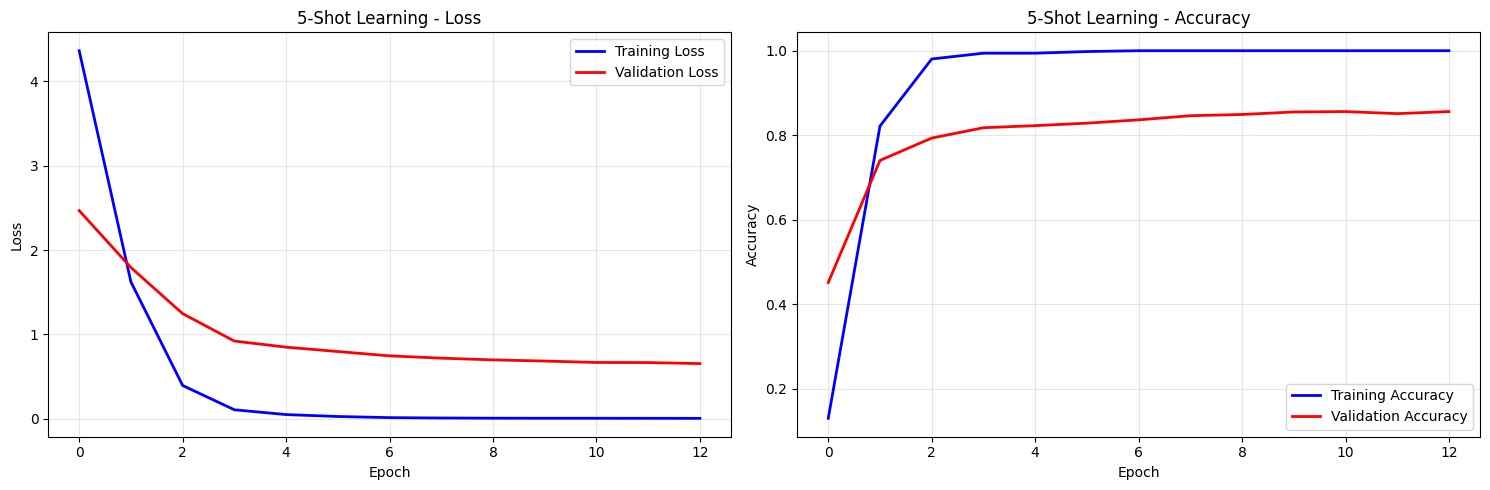

In [ ]:
plot_training_curves(history, title="5-Shot Learning")

<Figure size 1200x1000 with 0 Axes>

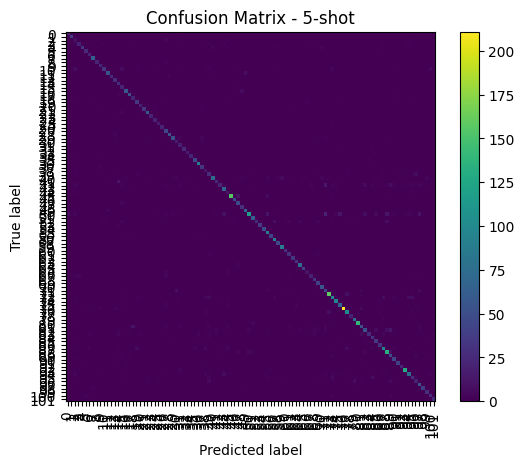

In [ ]:
# plot confusion matrix
cm_euc = confusion_matrix(labels_euc, preds_euc)
plt.figure(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_euc)
disp.plot(include_values=False, cmap='viridis', xticks_rotation='vertical')
plt.title("Confusion Matrix - 5-shot")
plt.show()

In [ ]:
# test and validation accuracy for 5-shot
val_preds_euc, val_labels_euc = evaluate_euclidean_with_cm(
    feature_extractor, prototypes_5, classes_5, val_loader
)

test_preds_euc, test_labels_euc = evaluate_euclidean_with_cm(
    feature_extractor, prototypes_5, classes_5, test_loader
)

val_acc_euc = (val_preds_euc == val_labels_euc).mean()
test_acc_euc = (test_preds_euc == test_labels_euc).mean()

print(f"[5-shot Val Acc:  {val_acc_euc * 100:.2f}%")
print(f"[5-shot Test Acc: {test_acc_euc * 100:.2f}%")

[5-shot Val Acc:  84.22%
[5-shot Test Acc: 80.70%
